Part A — meet the distributions

TASK 01

Sample and characterise all five

The curriculum's core activity: sample each distribution, plot it, compute its statistics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
print("ready")

ready


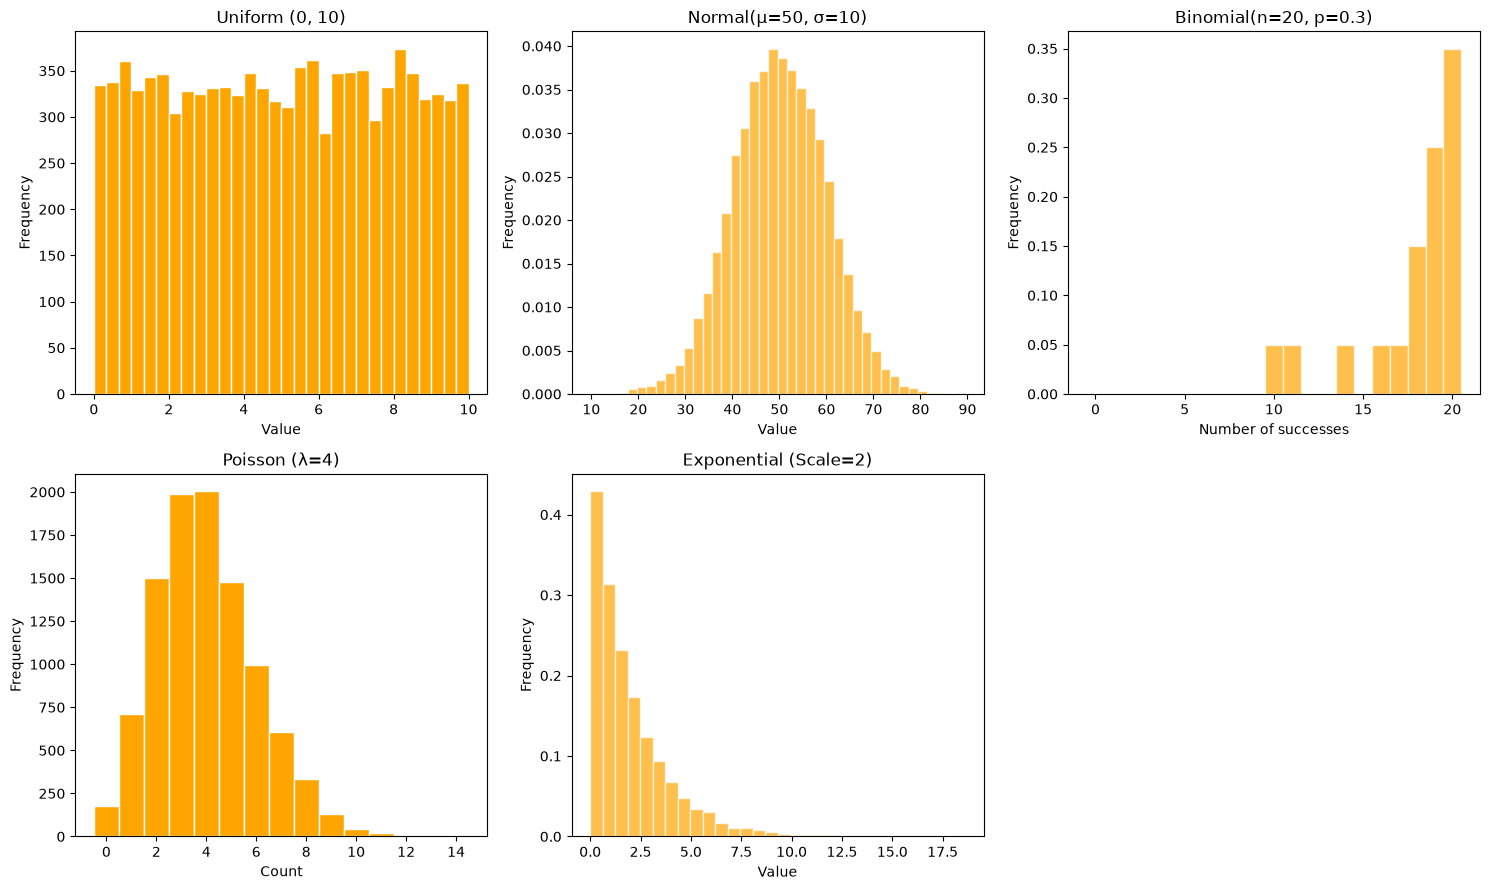

Distribution       Sample mean        Theory mean         Sample var           Theory var
Uniform                4.9941             5.0000          8.3550                8.3333
Normal                50.0445             50.0000          98.5139                100.0000
Binomial               5.9804             6.0000         4.1514                 4.2000
Poisson                  3.9940           4.0000             3.9930             4.0000
Exponential              1.9839           2.0000         3.8951               4.0000


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Random number generator
rng = np.random.default_rng(0)

# Generate 10,000 samples for each distribution
u = rng.uniform(0, 10, 10_000)
n = rng.normal(50, 10, 10_000)
b = rng.binomial(20, 0.3, 10_000)
p = rng.poisson(4, 10_000)
e = rng.exponential(2, 10_000)

# Theoretical values

# Uniform(a, b)
uniform_mean = (0 + 10) / 2
uniform_var = (10 - 0)**2 / 12

# Normal(mu, sigma)
normal_mean = 50
normal_var = 10**2

# Binomial(n, q)
binomial_mean = 20*0.3
binomial_var = 20*0.3*(1 - 0.3)

# Poisson(lambda)
poisson_mean = 4
poisson_var = 4

# Exponential(Scale = 2)
# Lambda = 1/2
exponential_mean = 2
exponential_var = 2**2


# plot all five histograms
fig, ax = plt.subplots(2, 3, figsize=(15, 9))

# Uniform
ax[0, 0].hist(u, bins=30, color="orange", edgecolor="white")
ax[0, 0].set_title("Uniform (0, 10)")
ax[0, 0].set_xlabel("Value")
ax[0, 0].set_ylabel("Frequency")

# Normal
ax[0, 1].hist(n, bins=40, density=True, color="orange", edgecolor="white", alpha=0.7)
ax[0, 1].set_title("Normal(μ=50, σ=10)")
ax[0, 1].set_xlabel("Value")
ax[0, 1].set_ylabel("Frequency")

# Binomial
ax[0, 2].hist(n, bins=np.arange(-0.5, 21.5, 1), density=True, color="orange", edgecolor="white", alpha=0.7)
ax[0, 2].set_title("Binomial(n=20, p=0.3)")
ax[0, 2].set_xlabel("Number of successes")
ax[0, 2].set_ylabel("Frequency")

# Poisson
ax[1, 0].hist(p, bins=np.arange(-0.5, max(p) + 1.5, 1), color="orange", edgecolor="white")
ax[1, 0].set_title("Poisson (λ=4)")
ax[1, 0].set_xlabel("Count")
ax[1, 0].set_ylabel("Frequency")

# Exponential
ax[1, 1].hist(e, bins=30, density=True, color="orange", edgecolor="white", alpha=0.7)
ax[1, 1].set_title("Exponential (Scale=2)")
ax[1, 1].set_xlabel("Value")
ax[1, 1].set_ylabel("Frequency")

# Empty sixth subplot
ax[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Sample vs Theoretical values

print("Distribution       Sample mean        Theory mean         Sample var           Theory var")
print(f"Uniform                {u.mean():.4f}             "
      f"{uniform_mean:.4f}          {u.var():.4f}                "
      f"{uniform_var:.4f}")

print(f"Normal                {n.mean():.4f}             "
      f"{normal_mean:.4f}          {n.var():.4f}                "
      f"{normal_var:.4f}")

print(f"Binomial               {b.mean():.4f}             "
      f"{binomial_mean:.4f}         {b.var():.4f}                 "
      f"{binomial_var:.4f}")

print(f"Poisson                  {p.mean():.4f}           "
      f"{poisson_mean:.4f}             {p.var():.4f}             "
      f"{poisson_var:.4f}")

print(f"Exponential              {e.mean():.4f}           "
     f"{exponential_mean:.4f}         {e.var():.4f}               "
     f"{exponential_var:.4f}")

1. Uniform: Values between 0 and 10 occur with approximately equal frequency, resulting in a relatively flat histogram.

Real-world: It can model scenarios where all values ​​within a range are roughly equally likely, such as a random number between 0 and 10.

2. Normal: The data forms a symmetric, bell-shaped pattern around 50.

Real-world: It can model quantities such as human heights or measurement errors.

3. Binomial: It models the number of successes in 20 trials, and the expected number of successes here is 6.

Real-world: It can model the number of heads in 20 coin flips or the number of successful outcomes in 20 attempts.

4. Poisson: Here, both the mean and variance should be approximately 4, which is the signature property of the Poisson distribution.

Real-world: It can model the number of events occurring within a fixed time—such as customer arrivals in an hour.

5. Exponential: In the histogram, there will be a very high frequency of small values ​​initially, followed by a long, thin right tail—which is why it is called "front-loaded."

Real-world: It can model the waiting time until an event occurs—such as waiting for the next customer to arrive.

TASK 02

The 68-95-99.7 rule

Make the normal distribution's most useful property concrete.

In [30]:
import numpy as np
from scipy import stats

# Parameters
mu = 100
sigma = 15

# Random Generator
rng = np.random.default_rng(42)

# 100,000 samples
samples = rng.normal(mu, sigma, 100_000)

# Simulation: 1, 2, 3 SD
within1 = np.mean(np.abs(samples - mu) < sigma)
within2 = np.mean(np.abs(samples - mu) < 2 * sigma)
within3 = np.mean(np.abs(samples - mu) < 3 * sigma)

print("Simulation:")
print(f"Within 1 SD: {within1:.4f}")
print(f"Within 2 SD: {within2:.4f}")
print(f"Within 3 SD: {within3:.4f}")

# Theory using scipy.stats.norm.cdf
theory1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
theory2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
theory3 = stats.norm.cdf(3) - stats.norm.cdf(-3)

print("\nTheory:")
print(f"Within 1 SD: {theory1:.4f}")
print(f"Within 2 SD: {theory2:.4f}")
print(f"Within 3 SD: {theory3:.4f}")


# 2 SD above mean
# Fraction above μ + 2σ
above_2sd = 1 - stats.norm.cdf(2)
print(f"\nAbove 2 SD: {above_2sd:.4f}")


# Percentile of μ + 2σ
percentile_1sd = stats.norm.cdf(1) * 100
print(f"\nPercentile at 1 SD above mean: {percentile_1sd:.2f}")

Simulation:
Within 1 SD: 0.6817
Within 2 SD: 0.9536
Within 3 SD: 0.9970

Theory:
Within 1 SD: 0.6827
Within 2 SD: 0.9545
Within 3 SD: 0.9973

Above 2 SD: 0.0228

Percentile at 1 SD above mean: 84.13


Part B — the Central Limit Theorem

TASK 03

Verify the CLT empirically

The curriculum's headline: watch a bell curve emerge from a non-bell distribution.

n = 1, SD of averages = 1.0008
n = 2, SD of averages = 0.7102
n = 5, SD of averages = 0.4436
n = 10, SD of averages = 0.3160
n = 30, SD of averages = 0.1826


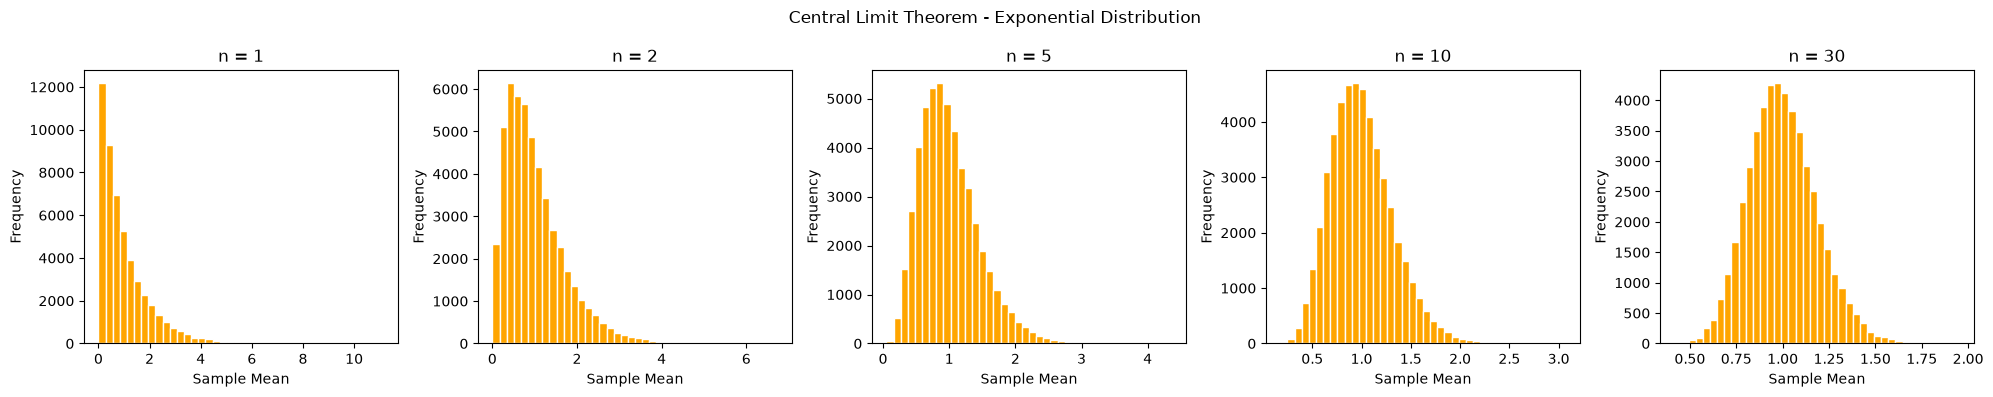

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Random number generator
rng = np.random.default_rng(42)

# Function to generate sample means
def sample_means(n, reps=50_000):
    return np.array([rng.exponential(1, n).mean()
                    for _ in range(reps)])

# Different sample sizes
sample_sizes = [1, 2, 5, 10, 30]

# Create 5 plots
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

for ax, n in zip(ax, sample_sizes):
    # Generate sample means
    means = sample_means(n)

    # Histogram
    ax.hist(means, bins=40, color="orange", edgecolor="white")

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Frequency")

    # Print standard deviation
    print(f"n = {n}, SD of averages = {means.std():.4f}")

fig.suptitle("Central Limit Theorem - Exponential Distribution")
plt.tight_layout()
plt.show()

The CLT explains why normal distributions appear so often in nature because many real-world measurements are influenced by the combined effect of many small, independent factors. When these factors are averaged together, their distribution tends to become approximately normal, even if the individual factors are not normally distributed.

Part C — PDF, CDF, and fitting

TASK 04

PDF and CDF

The two views of a distribution, and how to read probabilities off each.

----- Normal Distribution -----

Fraction below x = 1: 0.8413447460685429
Fraction below mean: 0.5
Fraction above x = 1: 0.15865525393145707
90th Percentile: 1.2815515655446004


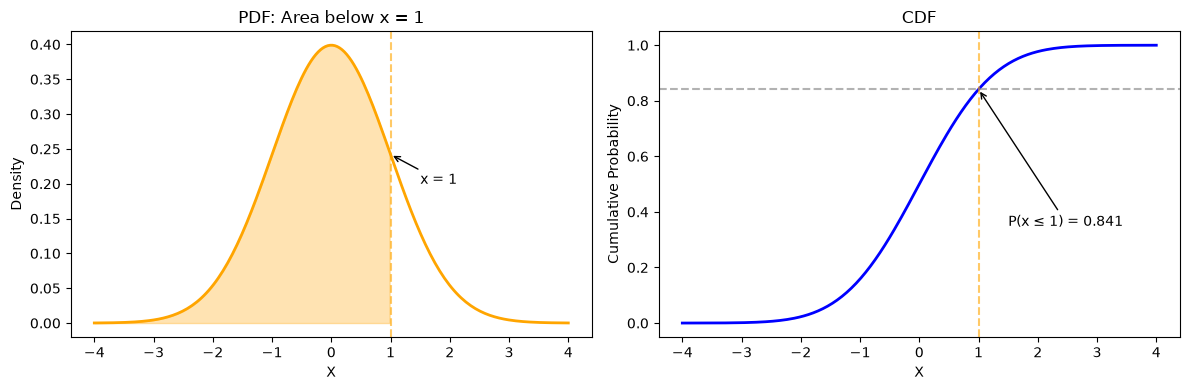

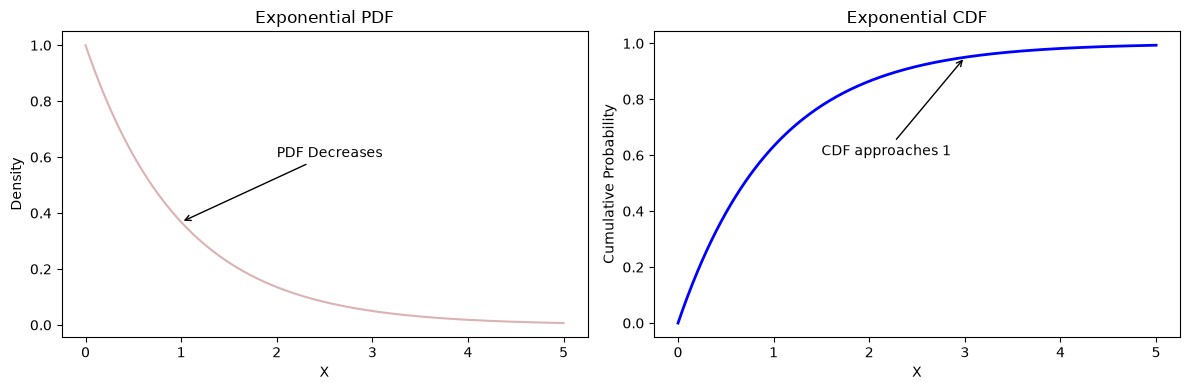

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Normal Distribution
x = np.linspace(-4, 4, 200)

pdf = stats.norm.pdf(x)
cdf = stats.norm.cdf(x)

x_value = 1

# Probability below x 
prob_below_x = stats.norm.cdf(x_value)

# Probability below mean
prob_below_mean = stats.norm.cdf(0)

# Probability above x
prob_above_x = 1 - prob_below_x

# 90th percentile
p90 = stats.norm.ppf(0.90)


print("----- Normal Distribution -----")
print("\nFraction below x = 1:", prob_below_x)
print("Fraction below mean:", prob_below_mean)
print("Fraction above x = 1:", prob_above_x)
print("90th Percentile:", p90)

# PDF + CDF with shaded area
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x, pdf, color="orange", lw=2)

x_shade = x[x <= x_value]
y_shade = stats.norm.pdf(x_shade)

ax[0].fill_between(x_shade, y_shade, color="orange", alpha=0.3)
ax[0].axvline(x_value, color="orange", ls="--", alpha=0.6)
ax[0].set_title("PDF: Area below x = 1")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Density")
ax[0].annotate("x = 1", xy=(x_value, stats.norm.pdf(x_value)), xytext=(1.5, 0.2), arrowprops=dict(arrowstyle="->"))

ax[1].plot(x, cdf, color="blue", lw=2)
ax[1].axvline(x_value, color="orange", ls="--", alpha=0.6)
ax[1].axhline(prob_below_x, color="gray", ls="--", alpha=0.6)
ax[1].plot(x_value, prob_below_x, color="black")
ax[1].set_title("CDF")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cumulative Probability")
ax[1].annotate(f"P(x ≤ 1) = {prob_below_x:.3f}", 
               xy=(x_value, prob_below_x), xytext=(1.5, 0.35), arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()


# Exponential Distribution
x_exp = np.linspace(0, 5, 500)

pdf_exp = stats.expon.pdf(x_exp)
cdf_exp = stats.expon.cdf(x_exp)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x_exp, pdf_exp, color="darkred", alpha=0.3)
ax[0].set_title("Exponential PDF")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Density")
ax[0].annotate(
    "PDF Decreases", 
    xy = (1, stats.expon.pdf(1)),
    xytext=(2, 0.6),
    arrowprops=dict(arrowstyle="->")
)

ax[1].plot(x_exp, cdf_exp, color="blue", lw=2)
ax[1].set_title("Exponential CDF")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cumulative Probability")
ax[1].annotate(
    "CDF approaches 1",
    xy = (3, stats.expon.cdf(3)),
    xytext=(1.5, 0.6),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

The PDF shows the density of values, while the CDF shows the cumulative probability up to a given value. For the normal distribution, the CDF reaches 0.5 at the mean, while for the skewed exponential distribution, the CDF rises rapidly near zero and gradually approaches 1.

TASK 05

Fit a distribution to real data

The curriculum's deliverable. Given data, find the distribution that produced it.

fitted normal: mean = 249.0, sd = 35.0


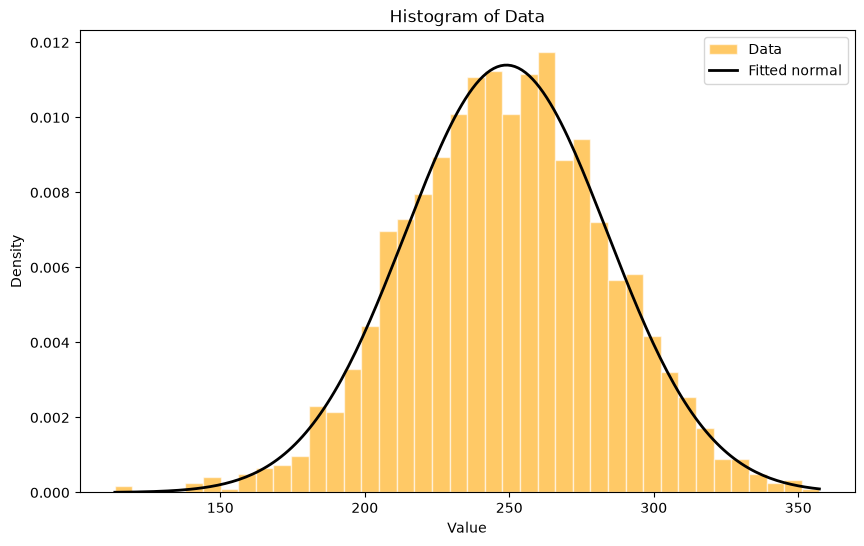

----- Fitted Parameters -----

Normal Distribution:
mu    : 5.247155229374255
sigma : 5.461460653461529

Exponential Distribution:
loc   : 0.035577063385797164
scale : 5.211578165988458


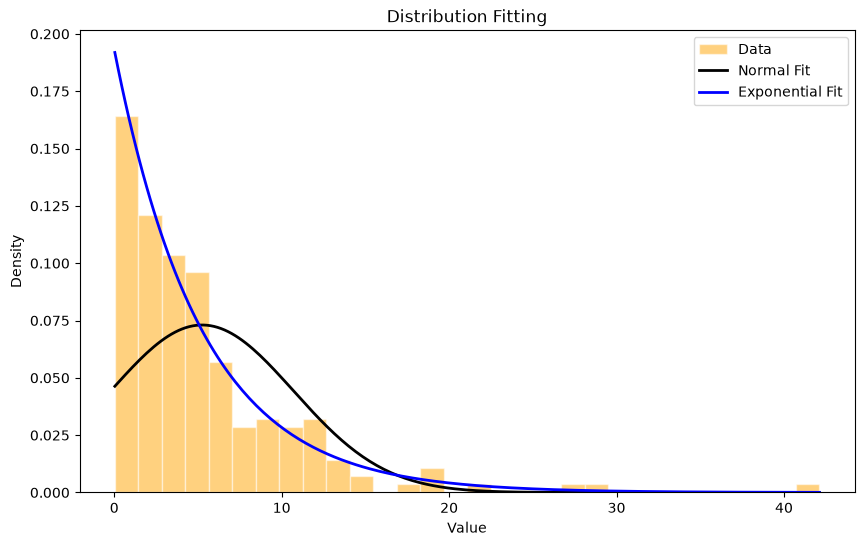


----- log-likelihood Comparison
Normal Log-likelihood      : -623.33
Exponential Log-likelihood : -530.18

----- Result -----
Best Fitting Distribution is Exponential Distribution


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate realistic data
rng = np.random.default_rng(0)

data = rng.normal(250, 35, size=2_000)

mu, sigma = stats.norm.fit(data)
print(f"fitted normal: mean = {mu:.1f}, sd = {sigma:.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data, bins=40, density=True, color="orange", edgecolor="white", alpha=0.6, label="Data")
x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black", lw=2, label="Fitted normal")
ax.set_title("Histogram of Data")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()

plt.show()


rng = np.random.default_rng(1)
data = rng.exponential(scale=5, size=2_00)

# Fit two candidate distribution

# Normal Distribution
mu, sigma = stats.norm.fit(data)

# Exponential Distribution
loc, scale = stats.expon.fit(data)

# Print fitted parameters
print("----- Fitted Parameters -----")

print("\nNormal Distribution:")
print("mu    :", mu)
print("sigma :", sigma)

print("\nExponential Distribution:")
print("loc   :", loc)
print("scale :", scale)


# Create x values for exponential data
x = np.linspace(data.min(), data.max(), 200)


# Calculate fitted probability density function

# Normal PDF
pdf_norm = stats.norm.pdf(x, mu, sigma)

# Exponential PDF
pdf_expon = stats.expon.pdf(x, loc, scale,)



# Plot histogram + Fitted curves

fig, ax = plt.subplots(figsize=(10, 6))

# Original data histogram
ax.hist(data, bins=30, density=True, color="orange", edgecolor="white", alpha=0.5, label="Data")

# Normal Fitted Curve
ax.plot(x, pdf_norm, color="black", lw=2, label="Normal Fit")

# Exponential Fitted Curve
ax.plot(x, pdf_expon, color="blue", lw=2, label="Exponential Fit")

ax.set_title("Distribution Fitting")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()

plt.show()



# Calculate log-likelihood

# Normal log-likelihood
ll_norm = np.sum(stats.norm.logpdf(data, mu, sigma))

# Exponential log-likelihood
ll_expon = np.sum(stats.expon.logpdf(data, loc, scale))

print("\n----- log-likelihood Comparison")
print(f"Normal Log-likelihood      : {ll_norm:.2f}")
print(f"Exponential Log-likelihood : {ll_expon:.2f}")


# Decide Which distribution fits better
if ll_norm > ll_expon:
    winner = "Normal Distribution"
else :
    winner = "Exponential Distribution"

print("\n----- Result -----")
print("Best Fitting Distribution is", winner)




The exponential distribution won because it had the higher log-likelihood and matched the right-skewed histogram better. This suggests that the data may have been generated by a process involving positive waiting times or events occurring at a roughly constant rate.